# Pre-requisites

   
The Hugging face library (needed for the second part of this lab)

    pip install transformers

In [ ]:
!pip install transformers

     |████████████████████████████████| 1.3MB 10.9MB/s 
     |████████████████████████████████| 2.9MB 56.6MB/s 
     |████████████████████████████████| 1.1MB 53.4MB/s 
     |████████████████████████████████| 890kB 31.9MB/s 
  Created wheel for sacremoses: filename=sacremoses-0.0.43-cp36-none-any.whl size=893257 sha256=fa0044993d404a96ece86ef07c89ed182cb43aafed322984651248268cb0f701
  Stored in directory: /root/.cache/pip/wheels/29/3c/fd/7ce5c3f0666dab31a50123635e6fb5e19ceb42ce38d4e58f45
Successfully built sacremoses


# BERT Embeddings

In [ ]:
import numpy as np
import pprint

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [ ]:
from transformers import BertTokenizer, BertTokenizerFast, BertModel
import torch

In [ ]:
# Colab Setup
# Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# After downloading the shared starting point folder as a Zip
# Unzip it and re-upload it to a location on your GDrive

# This command copies the contents from the folder you uploaded to GDrive, to the colab working dir
!cp -r /content/drive/My\ Drive/'Project RI 2020'/ProjectoRI2020 /content

# Add working dir to the sys path, so that we can find the aux python files when running the Notebook
import sys
if not '/content/ProjectoRI2020' in sys.path:
  sys.path += ['/content/ProjectoRI2020']

# Finally install required dependencies to run the notebook
!pip install elasticsearch
!pip install bert-serving-client


Mounted at /content/drive
     |████████████████████████████████| 327kB 19.8MB/s 


## Initialization, constants, sample texts

In [ ]:
bert_model_name = 'bert-base-cased'
bert_model_name = 'nboost/pt-bert-base-uncased-msmarco'
CLS_token = "[CLS]"
SEP_token = "[SEP]"

In [ ]:
import TRECCASTeval as trec
import numpy as np
import pandas as pd
import ElasticSearchSimpleAPI as es


elastic = es.ESSimpleAPI()
test_bed = trec.ConvSearchEvaluation()

triplets = [] #(utterance, passagem, relevance judgment) tuples

for index, row in test_bed.relevance_judgments.iterrows():
  if ('CAR' not in row['docid'] and 'WAPO' not in row['docid'] and 'MARCO_4286598' not in row['docid']):
    doc_body = elastic.get_doc_body(row['docid'])
    relev = row['rel']
    if(relev > 1):
      relev = 1
    turnId =  row['topic_turn_id'].split('_')
    triplets.append([test_bed.train_topics[int(turnId[0]) - 1]['turn'][int(turnId[1]) - 1]['raw_utterance'],doc_body, relev])
    print(turnId)
  print(index)


array = np.array(triplets)
df_triplets = pd.DataFrame(data = array, columns = ['topic_turn', 'passage', 'rel'])
df_triplets


ModuleNotFoundError: ignored

## Pre-processing

In [ ]:
#tokenizer = BertTokenizer.from_pretrained(bert_model_name)
tokenizer = BertTokenizerFast.from_pretrained(bert_model_name)

## BERT Model

In [ ]:
device = torch.device("cuda")

model = BertModel.from_pretrained('bert-base-uncased', return_dict=True)
model.eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0): BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          

## BERT for Learning to Rank

Recall this slide from the Learning to Rank lecture.

Goal:

*   You will use BERT to replace this whole set of individual features extracted from your collection;
*   Then, learn a classifier based on BERT features instead.

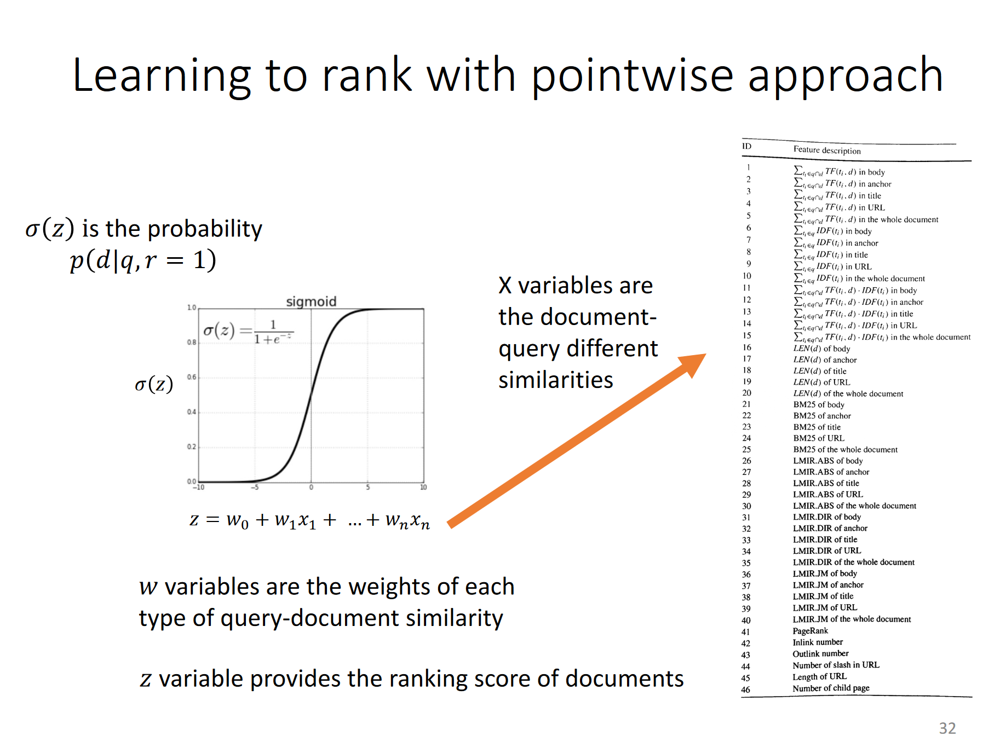

In [ ]:
# Receive a list of [query_text, doc_text] in variable sentences
# Returns a dictionary of tensors
# It can only receive a single pair [query_text, doc_text] each time
def convert_to_bert_input(sentences, max_seq_length=512, tokenizer=tokenizer, add_cls=True, padding='do_not_pad', truncation=False):
  return tokenizer.encode_plus(sentences, add_special_tokens=add_cls, padding=padding, max_length=max_seq_length, truncation=truncation,
                               return_tensors='pt', return_token_type_ids=True, return_attention_mask=True)



# Testing BERT with utterance - documents

In [ ]:
sentences = df_triplets[['topic_turn', 'passage']]
outputs = []
for index, sentence in sentences.iterrows():
  inputs_qa = convert_to_bert_input(sentences=sentence, max_seq_length=512, tokenizer=tokenizer, padding='max_length', truncation=False)

  input_ids = inputs_qa['input_ids']
  attention_mask = inputs_qa['attention_mask']
  token_type_ids = inputs_qa['token_type_ids']

  input_ids = input_ids.to(device)
  attention_mask = attention_mask.to(device)
  token_type_ids = token_type_ids.to(device)

  outputs_qa = model(**inputs_qa)

  outputs_qa = outputs_qa["last_hidden_state"][0,0].detach().clone()
  outputs.append(outputs_qa.numpy())
  print(index)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

KeyboardInterrupt: ignored

In [ ]:
import pickle
filename = 'trained_data'
outfile = open(filename, 'wb')
pickle.dump(xs,outfile)
outfile.close()


NameError: ignored

In [ ]:
import pickle
import joblib

filename = 'trained_data.pkl'
outputs =  pickle.load(open(filename, 'rb'))
infile.close()


[array([-3.69815707e-01,  5.34124792e-01, -7.12272763e-01,  6.06083721e-02,
        -7.27049768e-01, -1.74943618e-02,  7.37866879e-01,  1.03885162e+00,
        -2.65630424e-01, -4.11617577e-01, -4.91781563e-01, -6.03744313e-02,
        -1.07273012e-02,  5.94497204e-01,  4.39287424e-01,  6.02529682e-02,
         3.16143870e-01,  1.06738055e+00,  3.33900481e-01, -3.85541230e-01,
        -2.35022902e-01, -5.76210320e-01,  2.87799716e-01, -4.42540467e-01,
        -2.05430984e-01, -2.68648654e-01, -8.29192623e-02, -3.68894249e-01,
         8.29319134e-02, -7.73554325e-01, -3.87192070e-01,  1.53354362e-01,
        -2.41701305e-01, -3.83630067e-01,  4.50929701e-01,  1.02520540e-01,
         1.84724107e-01,  2.51825918e-02,  3.89597297e-01, -1.02629647e-01,
        -2.38872036e-01,  1.54836118e-01,  4.80863035e-01,  1.10082678e-01,
         3.50285381e-01, -8.43981504e-01, -2.60413170e+00, -5.95448911e-01,
        -3.29651892e-01,  3.44254315e-01, -1.98749527e-01, -2.72866637e-01,
         2.5

###Training

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

xs = outputs
ys = df_triplets['rel']



X_train, X_valid, Y_train, Y_valid = train_test_split(xs, ys, test_size=0.20, stratify=ys)

c_values =  [0.01*(2**i) for i in range(0,10)]
tol_values = [0.001*(2**i) for i in range(0,10)]
min_error = 100000
for c in c_values:
  for tole in tol_values:
    clf = LogisticRegression(random_state=0, C = c, tol= tole)

    clf.fit(X_train, Y_train)
    error = 1 - clf.score(X_valid, Y_valid)

    if(error < min_error):
      min_error = error
      best_model = clf

clf = best_model


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
xs = outputs
ys = df_triplets['rel']
clf = LogisticRegression(random_state=0)
clf.fit(xs,ys)

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=0, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()

# Create regularization penalty space
penalty = ['l1', 'l2']
max_iter = [100, 110, 130, 140, 150]
# Create regularization hyperparameter space
C = [0.01*(2**i) for i in range(0,10)]

tol = [0.01*(2**i) for i in range(0,10)]

# Create hyperparameter options
hyperparameters = dict(C=C, penalty=penalty, tol = tol, max_iter = max_iter)

clf = GridSearchCV(logistic, hyperparameters, cv=5, verbose=0)
xs = outputs
ys = df_triplets['rel']
clf.fit(xs, ys)

clf.best_estimator_.get_params()

Streaming output truncated to the last 5000 lines.
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. o

{'C': 0.01,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 5.12,
 'verbose': 0,
 'warm_start': False}

In [ ]:
duplets_test = []
for topic in test_bed.test_topics:
    conv_id = topic['number']
    for turn in topic['turn']:
        turn_id = turn['number']
        utterance = turn['raw_utterance']
        topic_turn_id = '%d_%d'% (conv_id, turn_id)

        result = elastic.search_body(query=utterance, numDocs = 10)
        for index, row in result.iterrows():
            doc_body = row['_source.body']
            duplets_test.append([utterance,doc_body])
        break
    break
    print(topic)
array_test = np.array(duplets_test)
df_duplets_test = pd.DataFrame(data = array_test, columns = ['topic_turn', 'passage'])
df_duplets_test

/content/ProjectoRI2020/ElasticSearchSimpleAPI.py:18: FutureWarning: pandas.io.json.json_normalize is deprecated, use pandas.json_normalize instead
  df = json_normalize(result["hits"]["hits"])


,topic_turn,passage
0,What is throat cancer?,There are two main types of throat cancer: Squ...
1,What is throat cancer?,This type of throat cancer is the most common ...
2,What is throat cancer?,Types of throat cancer. Throat cancer is a gen...
3,What is throat cancer?,Throat cancer refers to cancerous tumors that ...
4,What is throat cancer?,What is throat cancer? Throat cancer is any ca...
5,What is throat cancer?,Throat or larynx cancer. Throat cancer is canc...
6,What is throat cancer?,Types of Cancer: Throat Cancer. Throat cancer ...
7,What is throat cancer?,Throat cancer survival rate may differ dependi...
8,What is throat cancer?,Types of throat cancer. Throat cancer is a gen...
9,What is throat cancer?,What is throat cancer? Throat cancer is any ca...


In [ ]:
sentences = df_duplets_test[['topic_turn', 'passage']]
outputs = []
for index, sentence in sentences.iterrows():
  inputs_qa = convert_to_bert_input(sentences=sentence, max_seq_length=512, tokenizer=tokenizer, padding='max_length', truncation=False)

  input_ids = inputs_qa['input_ids']
  attention_mask = inputs_qa['attention_mask']
  token_type_ids = inputs_qa['token_type_ids']

  input_ids = input_ids.to(device)
  attention_mask = attention_mask.to(device)
  token_type_ids = token_type_ids.to(device)

  outputs_qa = model(**inputs_qa)

  outputs_qa = outputs_qa["last_hidden_state"][0,0].detach().clone()
  outputs.append(outputs_qa.numpy())
  print('------------------------------------')


------------------------------------
------------------------------------
------------------------------------
------------------------------------
------------------------------------
------------------------------------
------------------------------------
------------------------------------
------------------------------------
------------------------------------


In [ ]:
#a partir daqui não ta feito
import sklearn.metrics as mt
preds = clf.predict_proba(outputs)
print(preds)
print("FAM")
preds= preds[np.lexsort((preds[:, 0], ))]
print(preds)

[[0.7307794  0.2692206 ]
 [0.89863348 0.10136652]
 [0.45738023 0.54261977]
 [0.5637219  0.4362781 ]
 [0.82663496 0.17336504]
 [0.56254419 0.43745581]
 [0.50672846 0.49327154]
 [0.9829789  0.0170211 ]
 [0.27631148 0.72368852]
 [0.68883415 0.31116585]]
FAM
[[0.27631148 0.72368852]
 [0.45738023 0.54261977]
 [0.50672846 0.49327154]
 [0.56254419 0.43745581]
 [0.5637219  0.4362781 ]
 [0.68883415 0.31116585]
 [0.7307794  0.2692206 ]
 [0.82663496 0.17336504]
 [0.89863348 0.10136652]
 [0.9829789  0.0170211 ]]
